# Exploration des données CRM — Lumina & Co - TP1

4 tables disponibles :
- `customers` : profil et comportement d'achat des clients
- `transactions` : historique des achats produit par produit
- `touchpoints` : parcours marketing (canaux, campagnes, conversions)
- `campaigns` : performance agrégée par campagne

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA_DIR = "Lumina & Co - CRM/"

customers    = pd.read_csv(DATA_DIR + "customers.csv")
transactions = pd.read_csv(DATA_DIR + "transactions.csv")
touchpoints  = pd.read_csv(DATA_DIR + "touchpoints.csv")
campaigns    = pd.read_csv(DATA_DIR + "campaigns.csv")

print("Données chargées ✓")

Données chargées ✓


In [2]:
customers.head(5)

,customer_id,country,first_purchase,last_purchase,n_orders,total_spent,avg_basket,recency_days,tenure_days,declared_preference,age_bracket,life_stage,urban_density
0,56396,France,2026-05-18 00:00:00,2026-06-11 00:00:00,1,757.68,757.6800,19,24,NaN,NaN,NaN,Zone urbaine dense
1,14297,France,2025-09-28 19:41:00,2026-06-12 20:16:00,4,2325.35,581.3375,17,274,NaN,NaN,NaN,NaN
2,34160,France,2024-03-25 00:00:00,2025-06-03 00:00:00,1,519.12,519.1200,392,435,Peau sèche,45-54 ans,NaN,NaN
3,61352,France,2023-06-21 00:00:00,2025-03-02 00:00:00,4,6394.33,1598.5800,485,620,Peau sèche,35-44 ans,Jeune actif en solo,NaN
4,20612,France,2025-09-19 00:00:00,2026-06-17 00:00:00,9,5918.34,657.5900,13,271,NaN,NaN,NaN,NaN


In [3]:
transactions.head(500)

,invoice_id,customer_id,product_code,product_name,category,quantity,unit_price,invoice_date,country
0,509453,13381.0,82583,Savon Surgras Lavande,Corps,3,7.72,2024-12-12 20:59:00,France
1,558926,17469.0,23201,Lait Corps Amande Douce,Corps,1,18.21,2026-01-23 21:31:00,France
2,567853,15484.0,23289,Savon Surgras Lavande,Corps,1,7.53,2026-04-13 00:41:00,France
3,549949,13208.0,22289,Huile Démaquillante Camélia,Visage,1,22.84,2025-11-02 00:07:00,France
4,505081,16742.0,22607,Coffret Découverte Rituel Slow Beauty,Coffret,1,47.12,2024-11-08 20:59:00,France
...,...,...,...,...,...,...,...,...,...
495,556494,17802.0,23309,Huile Démaquillante Camélia,Visage,1,22.23,2026-01-01 02:07:00,France
496,575176,NaN,22602,Contour des Yeux Concombre,Visage,2,24.79,2026-05-30 05:39:00,France
497,648250,29751.0,20984,Contour des Yeux Concombre,Visage,2,25.95,2026-03-06 00:00:00,Germany
498,703236,41596.0,20665,Eau Micellaire Fleur d'Oranger,Visage,1,15.64,2026-03-04 00:00:00,France


In [4]:
print("\n\n------------------------------------------------ ETAPE 1 : Vue d'ensemble ----------------------------------------------")
print("   ")
print("\n====== TAILLE DES TABLES ======") 
print("1) Chargez les deux fichiers et répondez aux questions suivantes avant d'écrire la moindre ligne de nettoyage : Combien de clients ? Combien de transactions ?")                         
print(f"Customers      : {len(customers)} lignes")
print(f"Transactions : {len(transactions)} lignes")

print("\n====== PÉRIODE ======")
print("2) Sur quelle période ?")
transactions["invoice_date"] = pd.to_datetime(transactions["invoice_date"])
print(f"Transactions : {transactions['invoice_date'].min().date()} → {transactions['invoice_date'].max().date()}")

print("\n====== VALEURS MANQUANTES (%) ======")
print("3) Quelles colonnes contiennent des valeurs manquantes, et dans quelle proportion ?·")
for nom, table in [("customers", customers), ("transactions", transactions)]:
    manquantes = (table.isnull().mean() * 100).round(1)
    manquantes = manquantes[manquantes > 0]
    print(f"{nom}:")
    print(manquantes.to_string() if len(manquantes) else "  aucune")

print("\n====== TYPES DE DONNÉES ======")
print("4) Quels types de données sont attendus vs observés ?·")
for nom, table in [("customers", customers), ("transactions", transactions)]:
    print(f"{nom}:")
    print(table.dtypes.to_string())

print("\n====== DOUBLONS ======")
print("5) Y a-t-il des doublons ?")
for nom, table in [("customers", customers), ("transactions", transactions)]:
    nb_doublons = table.duplicated().sum()
    print(f"{nom} : {nb_doublons} doublon(s)")

print("\n PREMIERES OBSERVATIONS")
print("1. Différence entre 1st et last purchase pour des commandes uniques")
print("2. Variables object en type de données au lieu de string")
print("3. absence de données à + de 50% = révèle probablement une donnée Zero party qui reste interessante à valoriser. Ne pas oublier de le mentionner")
print("4. La france est le pays le plus représenté")
print("5. Pour product_name celui qui revient le plus c'est 'ajustement annuel'...")



------------------------------------------------ ETAPE 1 : Vue d'ensemble ----------------------------------------------
   

====== TAILLE DES TABLES ======
1) Chargez les deux fichiers et répondez aux questions suivantes avant d'écrire la moindre ligne de nettoyage : Combien de clients ? Combien de transactions ?
Customers      : 50295 lignes
Transactions : 1613433 lignes

====== PÉRIODE ======
2) Sur quelle période ?
Transactions : 2022-01-07 → 2026-06-30

====== VALEURS MANQUANTES (%) ======
3) Quelles colonnes contiennent des valeurs manquantes, et dans quelle proportion ?·
customers:
declared_preference    61.9
age_bracket            57.3
life_stage             77.5
urban_density          80.2
transactions:
customer_id     22.8
product_name     0.1

====== TYPES DE DONNÉES ======
4) Quels types de données sont attendus vs observés ?·
customers:
customer_id              int64
country                    str
first_purchase             str
last_purchase              str
n_orders   

In [10]:
print("\n\n------------------------------------ ETAPE 2 : Détection et traitement des anomalies ------------------------------------")
print("   ")
print("\n\n====== DANS 'TRANSACTIONS' ======")
print("1) Les 'customer_id' manquants : que représentent ces lignes ? Faut-il les supprimer ou les conserver ?")
print("--> Réponse : Dans transactions.csv, customer_id est la clé qui relie une transaction à un client identifié dans customers.csv. Donc une ligne sans customer_id = un achat fait par quelqu'un qui n'est pas dans la base clients. Typiquement un achat en mode invité (guest checkout), sans compte créé. Ces lignes sont quand même des ventes réelles, donc on ne les supprime pas pour l'analyse du chiffre d'affaires mais on les exclut quand on analyse les comportements clients (segmentation,fidélité, etc.) puisque nous n'avons pas de profil associé")


print("\n2) Les 'quantity' négatives : d'où viennent-elles ? Quel impact sur les agrégations futures ?")
print("--> Réponse : Ce sont des retours produits. On les conserve mais on les exclut des analyses de CA et de fréquence d'achat pour ne pas sous-estimer les chiffres.")
qty_negatives = transactions[transactions["quantity"] < 0]
print(f"Lignes avec quantity négative : {len(qty_negatives)} ({len(qty_negatives)/len(transactions)*100:.1f}%)")
print(qty_negatives[["invoice_id", "product_name", "quantity", "unit_price"]].head(5))


print("\n3) Les 'unit_price' à zéro : anomalie ou cas métier légitime ?")
print("--> Réponse : Probablement des échantillons offerts ou des gestes commerciaux. Ce ne sont pas des erreurs mais c'est probablement un cas métier légitime. On les signale mais on les garde.")
prix_zero = transactions[transactions["unit_price"] == 0]
print(f"Lignes avec unit_price = 0 : {len(prix_zero)} ({len(prix_zero)/len(transactions)*100:.1f}%)")
print(prix_zero[["product_code", "product_name", "quantity"]].value_counts().head(10))


print("\n4) Les 'product_code' atypiques : identifiez les codes non-produits (frais de port, ajustements comptables, etc.)")
print("--> Réponse : Un premier test sur 'non-numérique' était trop large : il capturait aussi de vrais codes produits alphanumériques (ex: 85123A, 82494L), soit 193 905 lignes de vraies ventes exclues à tort (12% du dataset). On utilise à la place une liste explicite des codes non-produits connus (frais de port, ajustements manuels, échantillons, dons, frais bancaires) — bien plus précis et documentable.")
codes_non_produits = ["POST", "M", "S", "DOT", "C2", "AMAZONFEE", "BANK CHARGES", "CRUK"]
transactions["code_atypique"] = transactions["product_code"].isin(codes_non_produits)
codes_atypiques = transactions[transactions["code_atypique"]]
print(f"Lignes avec code atypique : {len(codes_atypiques)} ({len(codes_atypiques)/len(transactions)*100:.1f}%)")
print(codes_atypiques[["product_code", "product_name"]].value_counts().head(15))


print("\n5) Calculez 'line_total' = quantity × unit_price. Vérifiez la cohérence.")
transactions["line_total"] = transactions["quantity"] * transactions["unit_price"]
print("line_total créé")

print("\n\n====== DANS 'CUSTOMERS' ======")
print("1) Cohérence des dates (`first_purchase` ≤ `last_purchase`)")
print("--> Réponse : Pour n_orders == 1, first et last purchase devraient être identiques. Si elles diffèrent, c'est une erreur d'export CRM ou n_orders est sous-compté. Anomalie à documenter.")
customers["first_purchase"] = pd.to_datetime(customers["first_purchase"])
customers["last_purchase"]  = pd.to_datetime(customers["last_purchase"])
print("\nCas 1 : first_purchase > last_purchase (logiquement impossible)")
dates_inversees = customers[customers["first_purchase"] > customers["last_purchase"]]
print(f"Clients avec first_purchase > last_purchase : {len(dates_inversees)}")
print("\nCas 2 : 1 seule commande mais first_purchase ≠ last_purchase (incohérent)")
one_order_dates_differentes = customers[
    (customers["n_orders"] == 1) &
    (customers["first_purchase"] != customers["last_purchase"])]
print(f"Clients avec 1 commande mais dates différentes : {len(one_order_dates_differentes)}")
print(one_order_dates_differentes[["customer_id", "n_orders", "first_purchase", "last_purchase"]].head(10))

print("2) Valeurs aberrantes dans 'total_spent', 'n_orders', 'avg_basket'")
print("--> Réponse : Si le max est très éloigné du 75e percentile, ce sont des clients B2B ou revendeurs. À documenter comme limite de la base.")
for colonne in ["total_spent", "n_orders", "avg_basket"]:
    print(f"\n--- {colonne} ---")
    print(customers[colonne].describe().round(2))


print("\n2) Clients avec une seule transaction vs clients récurrents : quelle proportion ?")
one_shot   = customers[customers["n_orders"] == 1]
recurrents = customers[customers["n_orders"] > 1]
total = len(customers)
print(f"One-shot   : {len(one_shot)} clients ({len(one_shot)/total*100:.1f}%)")
print(f"Récurrents : {len(recurrents)} clients ({len(recurrents)/total*100:.1f}%)")
print(f"Panier moyen one-shot   : {one_shot['avg_basket'].mean():.2f} €")
print(f"Panier moyen récurrents : {recurrents['avg_basket'].mean():.2f} €")




------------------------------------ ETAPE 2 : Détection et traitement des anomalies ------------------------------------
   


====== DANS 'TRANSACTIONS' ======
1) Les 'customer_id' manquants : que représentent ces lignes ? Faut-il les supprimer ou les conserver ?
--> Réponse : Dans transactions.csv, customer_id est la clé qui relie une transaction à un client identifié dans customers.csv. Donc une ligne sans customer_id = un achat fait par quelqu'un qui n'est pas dans la base clients. Typiquement un achat en mode invité (guest checkout), sans compte créé. Ces lignes sont quand même des ventes réelles, donc on ne les supprime pas pour l'analyse du chiffre d'affaires mais on les exclut quand on analyse les comportements clients (segmentation,fidélité, etc.) puisque nous n'avons pas de profil associé

2) Les 'quantity' négatives : d'où viennent-elles ? Quel impact sur les agrégations futures ?
--> Réponse : Ce sont des retours produits. On les conserve mais on les exclut des analyses 



------------------------------------ ETAPE 3 : Analyse exploratoire orientée marketing ------------------------------------


============ DISTRIBUTION DES ACHATS ============

1) Distribution du montant des paniers (attention aux outliers : clients B2B ?)
count    230836.000000
mean        222.211288
std         681.271395
min           0.030000
25%          45.420000
50%          93.530000
75%         167.190000
max       43920.100000
Name: montant_panier, dtype: float64

99e percentile (seuil B2B potentiel) : 2322.42 €
Commandes probablement B2C : 228527
Commandes probablement B2B : 2309(1.0%)
Clients B2B identifiés : 666
 
Montant panier APRÈS filtre (B2C uniquement) :
count    228527.000000
mean        174.559587
std         283.974445
min           0.030000
25%          44.980000
50%          92.360000
75%         163.690000
max        2322.280000
Name: montant_panier, dtype: float64


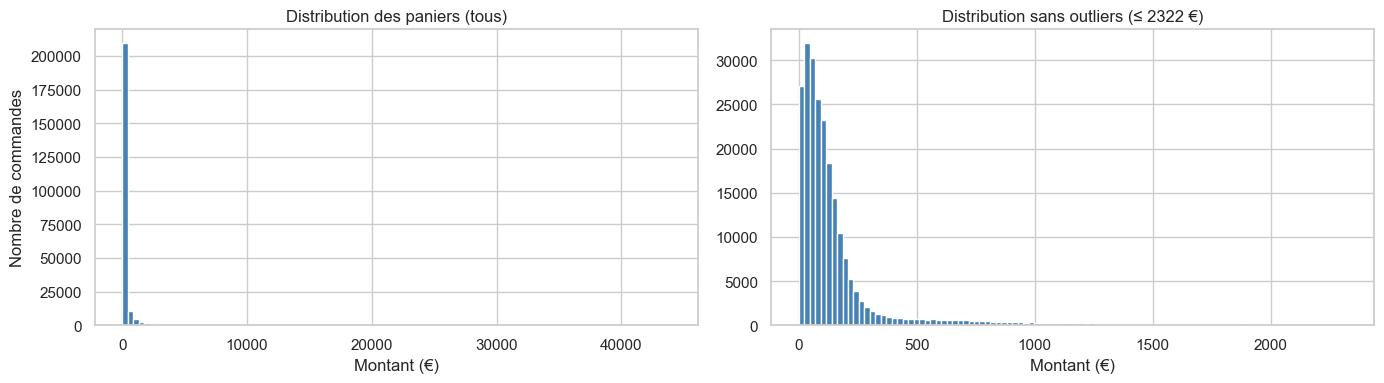

 

2) Distribution de la fréquence d'achat par client
--> Réponse :  On regarde combien de commandes chaque client a passé sur la période.
n_orders
1     14460
2      8425
3      6421
4      4170
5      3048
6      2403
7      2048
8      1680
9      1245
10     1108
Name: count, dtype: int64


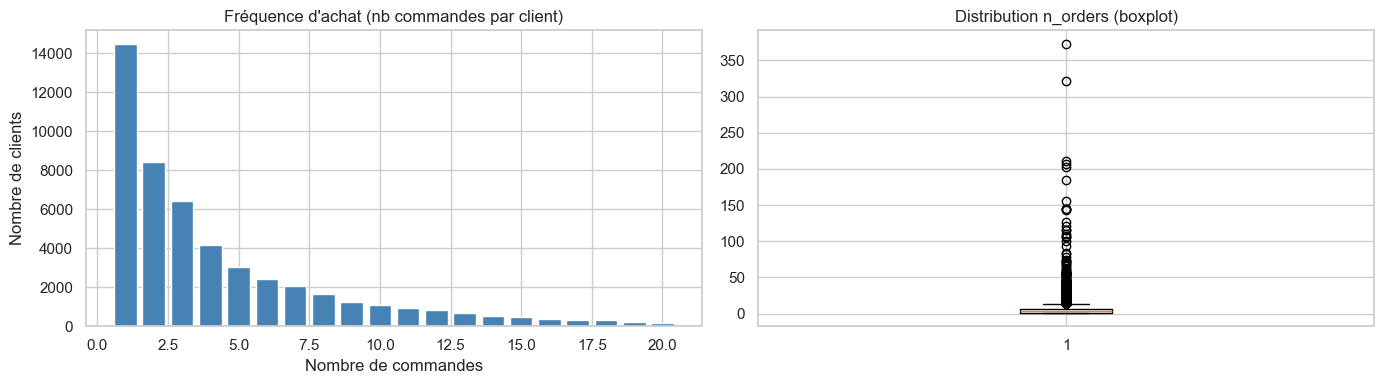


3) Loi de Pareto : quelle proportion de clients génère 80% du CA ?
--> 17266 clients (34.3%) génèrent 80% du CA


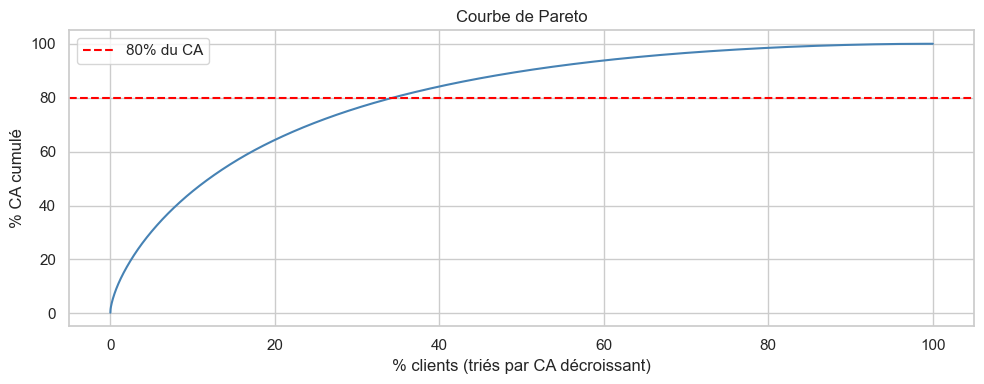




============ SAISONNALITÉ ============

1) Évolution du chiffre d'affaires mensuel sur la période disponible
--> Réponse : Les pics visibles correspondent aux périodes promotionnelles (rentrée, Black Friday, fêtes). À croiser avec les campagnes marketing.


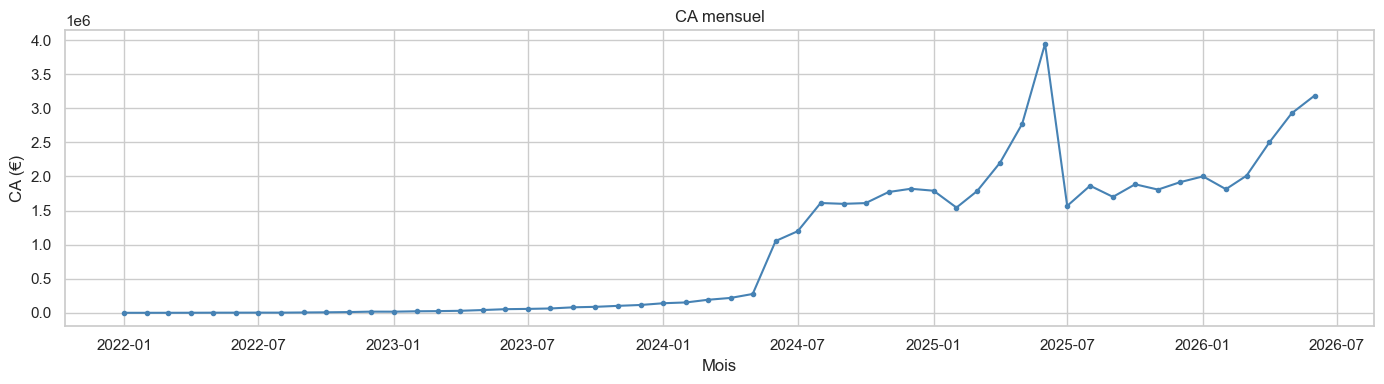


2) Y a-t-il des pics saisonniers visibles ?
mois_numero
1     3949384.67
2     3531614.30
3     4013565.75
4     4952226.45
5     6015428.44
6     8239776.85
7     2824988.61
8     3540686.87
9     3384267.93
10    3589285.80
11    3691868.21
12    3867976.00
Name: line_total, dtype: float64


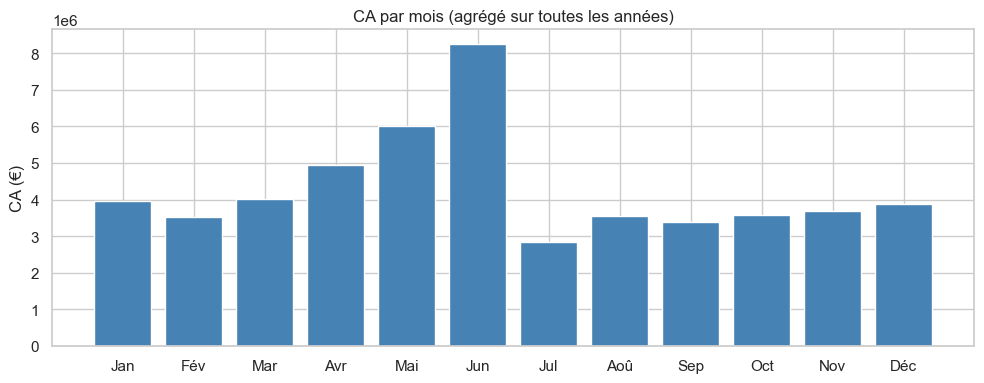


3) Produits les plus vendus en juin
product_name
Trousse Voyage Rechargeable          14433
Savon Surgras Lavande                13974
Crème Jour Karité Vanille            13473
Contour des Yeux Concombre           13157
Sérum Visage Bio Rose Musquée        13066
Huile Capillaire Ricin Bio           12908
Huile de Bain Relaxante Camomille    12770
Éponge Konjac Charbon                12630
Eau Micellaire Fleur d'Oranger       12311
Beurre Corporel Cacao Karité         12282
Name: quantity, dtype: int64

4) Saison avec le plus d'achats isolés (one-shot)
saison
Printemps    4554
Été          3364
Hiver        2962
Automne      2723
Name: customer_id, dtype: int64



============ GÉOGRAPHIE ============

1) Répartition des clients par pays
--> Réponse : Si un pays est surreprésenté, les segments créés refléteront ce biais. À documenter comme limite de l'analyse.
country
France                  45904
Germany                   918
United Kingdom            760
Spain                     291

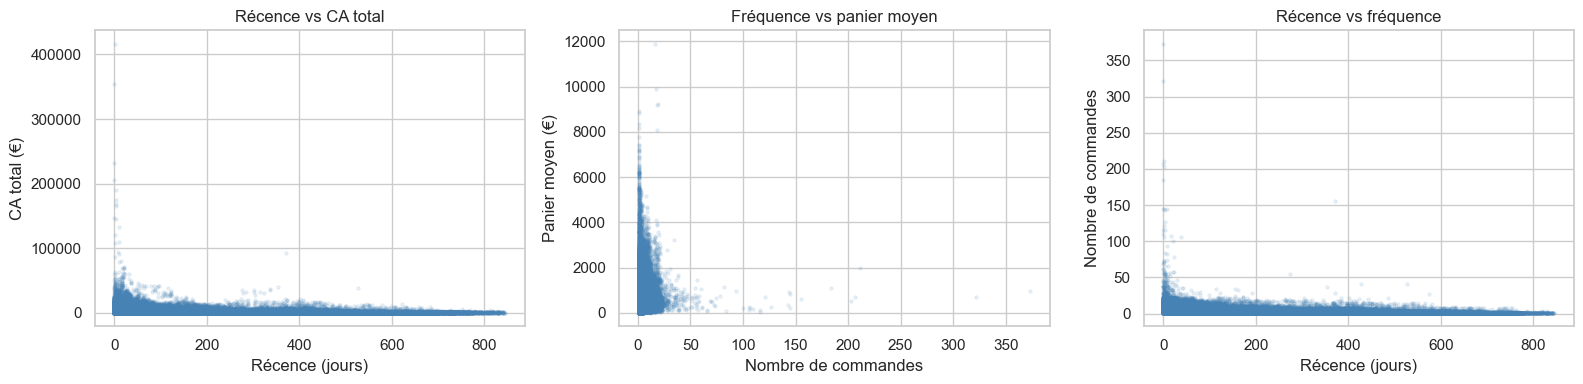


Matrice de corrélation :
              recency_days  total_spent  n_orders  avg_basket
recency_days          1.00        -0.27     -0.33       -0.09
total_spent          -0.27         1.00      0.72        0.44
n_orders             -0.33         0.72      1.00        0.01
avg_basket           -0.09         0.44      0.01        1.00



====== CATEGORIE PRODUITS ======

1) Quelle est la répartiation du chiffre d'affaires par 'category' ?
  category  chiffre_affaires  part_pct
    Visage       16161314.09      31.9
     Corps       10518610.35      20.8
   Coffret       10442649.67      20.6
   Cheveux        5758653.00      11.4
Accessoire        4118987.69       8.1
      Bain        3595274.97       7.1
     Frais          16707.38       0.0


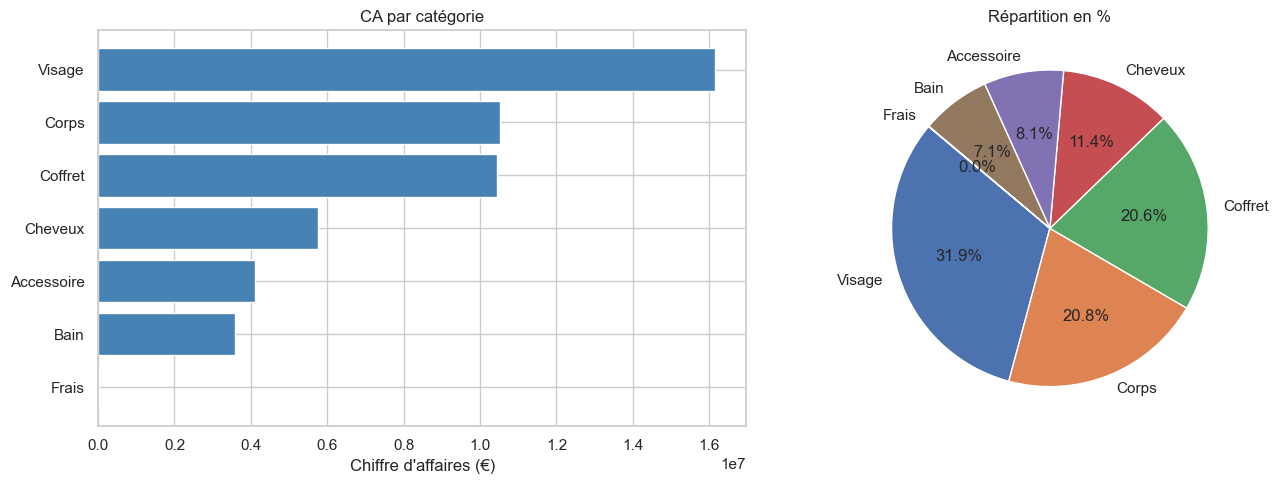


2) Une catégorie domine-t-elle, ou la répartition est-elle équilibrée ?
--> La catégorie 'Visage' domine avec 31.9% du CA.
--> Réponse :  La répartition n'est pas équilibrée car une ou deux catégories concentrent l'essentiel des ventes.

3) Ce premier regard servira de point de comparaison en Jour 2
--> Réponse : on cherchera si certains segments RFM ont une affinité particulière pour une catégorie.



====== DONNÉES ZERO-PARTY ======

1) Taux de remplissage des colonnes zero-party
--> Réponse : Des taux de remplissage entre 20% et 40% sont cohérents avec une donnée zero-party (déclarée volontairement). Ce n'est pas une anomalie mais une limite à mentionner : les segments construits sur ces variables ne couvriront qu'une fraction de la base.
declared_preference       : 38.1% renseigné
age_bracket               : 42.7% renseigné
life_stage                : 22.5% renseigné
urban_density             : 19.8% renseigné

2) Répartition des valeurs pour chaque colonne

--- declared_preferenc

In [11]:
print("\n\n------------------------------------ ETAPE 3 : Analyse exploratoire orientée marketing ------------------------------------")
print("\n\n============ DISTRIBUTION DES ACHATS ============")
print("\n1) Distribution du montant des paniers (attention aux outliers : clients B2B ?)")
transactions["line_total"] = transactions["quantity"] * transactions["unit_price"]
panier_par_commande = transactions.groupby("invoice_id")["line_total"].sum().reset_index()
panier_par_commande.columns = ["invoice_id", "montant_panier"]

# On enlève les paniers négatifs (retours) pour cette analyse
paniers_positifs = panier_par_commande[panier_par_commande["montant_panier"] > 0]
print(paniers_positifs["montant_panier"].describe())

# Seuil au-dessus duquel on considère un achat potentiellement B2B
# On utilise le 99e percentile comme repère
seuil_b2b = paniers_positifs["montant_panier"].quantile(0.99)
print(f"\n99e percentile (seuil B2B potentiel) : {seuil_b2b:.2f} €")
paniers_b2c = paniers_positifs[paniers_positifs["montant_panier"] <= seuil_b2b]
paniers_b2b = paniers_positifs[paniers_positifs["montant_panier"] > seuil_b2b]
print(f"Commandes probablement B2C : {len(paniers_b2c)}")
print(f"Commandes probablement B2B : {len(paniers_b2b)}({len(paniers_b2b)/len(paniers_positifs)*100:.1f}%)")
suspects_b2b = set(transactions[transactions["invoice_id"].isin(paniers_b2b["invoice_id"])]["customer_id"].dropna().unique())
print(f"Clients B2B identifiés : {len(suspects_b2b)}")
print(" ")
print("Montant panier APRÈS filtre (B2C uniquement) :")
print(paniers_b2c["montant_panier"].describe())


# Distribution visuelle
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Avec outliers
axes[0].hist(paniers_positifs["montant_panier"], bins=100, color="steelblue",
edgecolor="white")
axes[0].set_title("Distribution des paniers (tous)")
axes[0].set_xlabel("Montant (€)")
axes[0].set_ylabel("Nombre de commandes")

# Sans outliers B2B — on voit mieux la masse
axes[1].hist(paniers_b2c["montant_panier"], bins=100, color="steelblue",
edgecolor="white")
axes[1].set_title(f"Distribution sans outliers (≤ {seuil_b2b:.0f} €)")
axes[1].set_xlabel("Montant (€)")
plt.tight_layout()
plt.show()
print(" ")
print


print("\n2) Distribution de la fréquence d'achat par client")
print("--> Réponse :  On regarde combien de commandes chaque client a passé sur la période.")
frequence_par_client = customers["n_orders"].value_counts().sort_index()
print(frequence_par_client.head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(frequence_par_client.index[:20], frequence_par_client.values[:20], color="steelblue")
axes[0].set_title("Fréquence d'achat (nb commandes par client)")
axes[0].set_xlabel("Nombre de commandes")
axes[0].set_ylabel("Nombre de clients")
axes[1].boxplot(customers["n_orders"])
axes[1].set_title("Distribution n_orders (boxplot)")
plt.tight_layout()
plt.show()

print("\n3) Loi de Pareto : quelle proportion de clients génère 80% du CA ?")
ca_par_client = customers[["customer_id", "total_spent"]].sort_values("total_spent", ascending=False).copy()
ca_par_client["ca_cumule_pct"] = ca_par_client["total_spent"].cumsum() / ca_par_client["total_spent"].sum() * 100
ca_par_client["clients_pct"]   = range(1, len(ca_par_client) + 1)
ca_par_client["clients_pct"]   = ca_par_client["clients_pct"] / len(ca_par_client) * 100
seuil_pareto = ca_par_client[ca_par_client["ca_cumule_pct"] <= 80].shape[0]
print(f"--> {seuil_pareto} clients ({seuil_pareto/len(ca_par_client)*100:.1f}%) génèrent 80% du CA")

plt.figure(figsize=(10, 4))
plt.plot(ca_par_client["clients_pct"], ca_par_client["ca_cumule_pct"], color="steelblue")
plt.axhline(80, color="red", linestyle="--", label="80% du CA")
plt.xlabel("% clients (triés par CA décroissant)")
plt.ylabel("% CA cumulé")
plt.title("Courbe de Pareto")
plt.legend()
plt.tight_layout()
plt.show()



print("\n\n\n============ SAISONNALITÉ ============")
print("\n1) Évolution du chiffre d'affaires mensuel sur la période disponible")
print("--> Réponse : Les pics visibles correspondent aux périodes promotionnelles (rentrée, Black Friday, fêtes). À croiser avec les campagnes marketing.")
transactions_positives = transactions[transactions["line_total"] > 0].copy()
transactions_positives["mois"] = transactions_positives["invoice_date"].dt.to_period("M")
ca_mensuel = transactions_positives.groupby("mois")["line_total"].sum().reset_index()
ca_mensuel["mois_dt"] = ca_mensuel["mois"].dt.to_timestamp()

plt.figure(figsize=(14, 4))
plt.plot(ca_mensuel["mois_dt"], ca_mensuel["line_total"], color="steelblue", marker="o", markersize=3)
plt.title("CA mensuel")
plt.xlabel("Mois")
plt.ylabel("CA (€)")
plt.tight_layout()
plt.show()

print("\n2) Y a-t-il des pics saisonniers visibles ?")
transactions_positives["mois_numero"] = transactions_positives["invoice_date"].dt.month
ca_par_mois = transactions_positives.groupby("mois_numero")["line_total"].sum()
print(ca_par_mois)
plt.figure(figsize=(10, 4))
plt.bar(ca_par_mois.index, ca_par_mois.values, color="steelblue")
plt.xticks(range(1, 13), ["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"])
plt.title("CA par mois (agrégé sur toutes les années)")
plt.ylabel("CA (€)")
plt.tight_layout()
plt.show()

transactions["mois"] = transactions["invoice_date"].dt.month
transactions["saison"] = transactions["mois"].map({
      12: "Hiver", 1: "Hiver", 2: "Hiver",
      3: "Printemps", 4: "Printemps", 5: "Printemps",
      6: "Été", 7: "Été", 8: "Été",
      9: "Automne", 10: "Automne", 11: "Automne"})
  
# Produit le plus vendu en juin (par quantité)
print("\n3) Produits les plus vendus en juin")
ventes_juin = transactions[transactions["mois"] == 5]
print(ventes_juin.groupby("product_name")["quantity"].sum().sort_values(ascending=False).head(10))

# Saison qui provoque le plus d'achats isolés (clients avec 1 seule commande)
print("\n4) Saison avec le plus d'achats isolés (one-shot)")
one_shot_ids = customers[customers["n_orders"] == 1]["customer_id"]
transactions_one_shot = transactions[transactions["customer_id"].isin(one_shot_ids)]
print(transactions_one_shot.groupby("saison")["customer_id"].nunique().sort_values(ascending=False))



print("\n\n\n============ GÉOGRAPHIE ============")
print("\n1) Répartition des clients par pays")
print("--> Réponse : Si un pays est surreprésenté, les segments créés refléteront ce biais. À documenter comme limite de l'analyse.")
clients_par_pays = customers["country"].value_counts()
print(clients_par_pays)

print("\n2) Comportements d'achat selon le pays (panier moyen et fréquence)")
comportement_par_pays = customers.groupby("country").agg(
    nb_clients    = ("customer_id", "count"),
    panier_moyen  = ("avg_basket", "mean"),
    commandes_moy = ("n_orders", "mean")
).round(2).sort_values("nb_clients", ascending=False)
print(comportement_par_pays)



print("\n\n\n============ RELATIONS ENTRE VARIABLES ============")
print("\n1) Corrélation entre récence et montant dépensé")
print("--> Réponse :  Est-ce que les clients qui ont acheté récemment dépensent plus ?")
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(customers["recency_days"], customers["total_spent"], alpha=0.1, color="steelblue", s=5)
axes[0].set_xlabel("Récence (jours)")
axes[0].set_ylabel("CA total (€)")
axes[0].set_title("Récence vs CA total")

print("\n2) Relation entre fréquence et panier moyen")
print("--> Les clients fréquents dépensent-ils plus par visite ?")
axes[1].scatter(customers["n_orders"], customers["avg_basket"], alpha=0.1, color="steelblue", s=5)
axes[1].set_xlabel("Nombre de commandes")
axes[1].set_ylabel("Panier moyen (€)")
axes[1].set_title("Fréquence vs panier moyen")

print("\n3) Y a-t-il des segments naturellement visibles ?")
axes[2].scatter(customers["recency_days"], customers["n_orders"], alpha=0.1, color="steelblue", s=5)
axes[2].set_xlabel("Récence (jours)")
axes[2].set_ylabel("Nombre de commandes")
axes[2].set_title("Récence vs fréquence")

plt.tight_layout()
plt.show()

corr = customers[["recency_days", "total_spent", "n_orders", "avg_basket"]].corr().round(2)
print("\nMatrice de corrélation :")
print(corr)


print("\n\n\n====== CATEGORIE PRODUITS ======")
print("\n1) Quelle est la répartiation du chiffre d'affaires par 'category' ?")
ca_par_categorie = transactions.groupby("category")["line_total"].sum().reset_index()
ca_par_categorie.columns = ["category", "chiffre_affaires"]
ca_par_categorie = ca_par_categorie.sort_values("chiffre_affaires", ascending=False)

# On calcule la part en pourcentage
ca_par_categorie["part_pct"] = (ca_par_categorie["chiffre_affaires"] / ca_par_categorie["chiffre_affaires"].sum() * 100).round(1)
print(ca_par_categorie.to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot
axes[0].barh(ca_par_categorie["category"], ca_par_categorie["chiffre_affaires"], color="steelblue")
axes[0].invert_yaxis()
axes[0].set_xlabel("Chiffre d'affaires (€)")
axes[0].set_title("CA par catégorie")

# Camembert
axes[1].pie(
ca_par_categorie["chiffre_affaires"],
labels=ca_par_categorie["category"],
autopct="%1.1f%%",
startangle=140)
axes[1].set_title("Répartition en %") 
plt.tight_layout()
plt.show()

print("\n2) Une catégorie domine-t-elle, ou la répartition est-elle équilibrée ?")
categorie_dominante = ca_par_categorie.iloc[0]
print(f"--> La catégorie '{categorie_dominante['category']}' domine avec {categorie_dominante['part_pct']}% du CA.")
print("--> Réponse :  La répartition n'est pas équilibrée car une ou deux catégories concentrent l'essentiel des ventes.")

print("\n3) Ce premier regard servira de point de comparaison en Jour 2")
print("--> Réponse : on cherchera si certains segments RFM ont une affinité particulière pour une catégorie.")


print("\n\n\n====== DONNÉES ZERO-PARTY ======")
print("\n1) Taux de remplissage des colonnes zero-party")
print("--> Réponse : Des taux de remplissage entre 20% et 40% sont cohérents avec une donnée zero-party (déclarée volontairement). Ce n'est pas une anomalie mais une limite à mentionner : les segments construits sur ces variables ne couvriront qu'une fraction de la base.")
colonnes_zero_party = ["declared_preference", "age_bracket", "life_stage", "urban_density"]
for colonne in colonnes_zero_party:
    taux_rempli = customers[colonne].notna().mean() * 100
    print(f"{colonne:25} : {taux_rempli:.1f}% renseigné")

print("\n2) Répartition des valeurs pour chaque colonne")
for colonne in colonnes_zero_party:
    print(f"\n--- {colonne} ---")
    print(customers[colonne].value_counts(dropna=False).head(10))

In [12]:
print("\n\n------------------------------------ ETAPE 4 : Analyse exploratoire orientée marketing ------------------------------------")
print("\n1) Sur la base de votre EDA, formulez 3 à 5 hypothèses que vous chercherez à valider ou invalider avec la segmentation du Jour 2.")
print("Format suggéré :'Je suppose que [observation EDA] implique [comportement client attendu], ce qui suggère [action marketing potentielle].'")
print("\nHYPOTHÈSES :")
print("H1 : Le biais B2B peut tromper l'analyse et l'étude")
print("H2 : saisonnalité --> la campagne de printemps est la plus efficace")
print("H3 : l'étude des segments pour le printemps permettra de révéler des leviers pour augmenter l'éfficacité des campagnes les moins efficaces")
print("H4 : le scoring permet d'identifier des profils et optimiser les choix de campagne")



------------------------------------ ETAPE 4 : Analyse exploratoire orientée marketing ------------------------------------

1) Sur la base de votre EDA, formulez 3 à 5 hypothèses que vous chercherez à valider ou invalider avec la segmentation du Jour 2.
Format suggéré :'Je suppose que [observation EDA] implique [comportement client attendu], ce qui suggère [action marketing potentielle].'

HYPOTHÈSES :
H1 : Le biais B2B peut tromper l'analyse et l'étude
H2 : saisonnalité --> la campagne de printemps est la plus efficace
H3 : l'étude des segments pour le printemps permettra de révéler des leviers pour augmenter l'éfficacité des campagnes les moins efficaces
H4 : le scoring permet d'identifier des profils et optimiser les choix de campagne


In [14]:
print("\n\n-------------------- ETAPE 5 : préparation d'un fichier clean pour customer et transaction en prévision du TP 2 ")
print("\n====== TRANSACTION ======")
print("On exclut les retours (quantity négative)")
print("On exclut les prix à zéro")
print("On exclut les codes atypiques (frais de port, ajustements). Les lignes ne sont pas supprimées.")
print("On exclut les transactions sans customer_id (uniquement pour les etudes de comportement)")
transactions_clean = transactions[(transactions["quantity"] > 0) & (transactions["unit_price"] > 0) & (~transactions["code_atypique"]) & (transactions["customer_id"].notna()) & (~transactions["customer_id"].isin(suspects_b2b))].copy()

print("\n====== CUSTOMER ======")
print("Décisions sur customers :")
print("  - 12825 clients avec n_orders==1 mais dates différentes → conservés (erreur CRM probable)")
print("  - Clients B2B identifiés (panier > 2237€) → exclus du fichier clean")
print("  - 0 doublon → rien à supprimer")
print("  - Colonnes zero-party incomplètes (20-40%) → conservées, limite documentée")
customers_clean = customers[~customers["customer_id"].isin(suspects_b2b)].copy()
print(f"transactions : {len(transactions)} → {len(transactions_clean)} lignes après nettoyage")
print(f"customers    : {len(customers)} → {len(customers_clean)} lignes")

import os
os.makedirs("clean_data", exist_ok=True)
transactions_clean.to_csv("clean_data/transactions_clean.csv", index=False)
customers_clean.to_csv("clean_data/customers_clean.csv", index=False)

print("Fichiers exportés ✓")



-------------------- ETAPE 5 : préparation d'un fichier clean pour customer et transaction en prévision du TP 2 

====== TRANSACTION ======
On exclut les retours (quantity négative)
On exclut les prix à zéro
On exclut les codes atypiques (frais de port, ajustements)
On exclut les transactions sans customer_id (uniquement pour les etudes de comportement)

====== CUSTOMER ======
Décisions sur customers :
  - 12825 clients avec n_orders==1 mais dates différentes → conservés (erreur CRM probable)
  - Clients B2B identifiés (panier > 2237€) → exclus du fichier clean
  - 0 doublon → rien à supprimer
  - Colonnes zero-party incomplètes (20-40%) → conservées, limite documentée
transactions : 1613433 → 862882 lignes après nettoyage
customers    : 50295 → 49629 lignes
Fichiers exportés ✓
